In [1]:
%%bash
#!/bin/bash
hostname



tri0005


In [3]:
%%bash
echo -e "\nCGroup Enforcement:"
if [ -f /sys/fs/cgroup/memory/memory.limit_in_bytes ]; then
    MEM_BYTES=$(cat /sys/fs/cgroup/memory/memory.limit_in_bytes)
    # Convert to GB (using 1024^3)
    echo "Memory Limit (CGroup): $(awk "BEGIN {print $MEM_BYTES/1024/1024/1024}") GB"
elif [ -f /sys/fs/cgroup/memory.max ]; then
    # CGroup v2
    MEM_MAX=$(cat /sys/fs/cgroup/memory.max)
    echo "Memory Limit (CGroup v2): $MEM_MAX"
fi

# 4. If using Slurm (common on HPC)
if command -v squeue >/dev/null 2>&1; then
    echo -e "\nSlurm Job Info:"
    squeue --me
fi


CGroup Enforcement:

Slurm Job Info:
          JOBID            USER        ACCOUNT           NAME  ST  TIME_LEFT     PARTITION NODES   CPUS NODELIST (REASON)
         972925        liuhon33    def-dfelsky jupyter_notebo   R    3:50:07       compute     1    192 tri0005 (None)


In [4]:
import os
os.getcwd()

'/scratch/liuhon33/parallel/AGPMicrobiomeHostPredictions'

In [5]:
# 0. Import Libraries 
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from tqdm.notebook import tqdm # for terminal progress tracking
import os
import time # used to time each cross validation
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

# 1. Configuration
otu_file_path = "./Data/Cleaned_data/AGP_Otu_Data.csv"
metadata_file_path = "./Data/Cleaned_data/processed_metadata.csv"
metadata_index_col = 'sample_name'
otu_index_col = 0

outer_cv_splits = 10
inner_cv_splits = 5
random_state_cv = 42 # AI loves this random seed for some reason
abundance_threshold = 0.0001

n_pcs_to_predict = 10     # How many PCs to use as targets for the RF models
n_pcs_to_explore = 10    # How many PCs to calculate for the exploratory plots

param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__min_samples_leaf': [5, 10, 20],
    'rf__max_depth': [None, 10, 20]
}

output_dir = "./hongrui_result/RF_on_PCA_Results/"
os.makedirs(output_dir, exist_ok=True)
# save trained objects
model_dir = "./RF_PCA_Trained_Models/"
os.makedirs(model_dir, exist_ok=True)

In [6]:
# 2. Load and Prepare Data
print("--- Loading data ---")
metadata_df = pd.read_csv(metadata_file_path, index_col=metadata_index_col)
otu_df = pd.read_csv(otu_file_path, index_col=otu_index_col)

common_samples = metadata_df.index.intersection(otu_df.index)
metadata_df = metadata_df.loc[common_samples]
otu_df = otu_df.loc[common_samples]
print(f"Data aligned. Found {len(common_samples)} common samples.")
print(f"Initial number of OTUs: {otu_df.shape[1]}")

# Filter OTU Table (KEEP AS-IS for now)
otu_rel_abund = otu_df.apply(lambda x: x / x.sum(), axis=1)
mean_rel_abund = otu_rel_abund.mean(axis=0)
otus_to_keep = mean_rel_abund[mean_rel_abund > abundance_threshold].index
otu_df_filtered = otu_df[otus_to_keep]
print(f"Number of OTUs after filtering: {otu_df_filtered.shape[1]}")

# Log Transform OTU Data (Y-base) # will edit later for the CLR transformation
otu_df_log_transformed = np.log1p(otu_df_filtered)
print("Applied log(x+1) transformation to OTU counts.")

# Prepare metadata predictors (X) (NO global imputation / NO global scaling) Usually Random Forest do not need for scaling
numeric_cols = metadata_df.select_dtypes(include=np.number).columns
X_metadata = metadata_df[numeric_cols]
print(f"Using {X_metadata.shape[1]} numeric metadata features as predictors.")

# --- 3. Exploratory PCA on Microbiome Data (KEEP AS-IS for now) ---
# NOTE: This exploratory PCA is fine for plots, but it is NOT used for model targets anymore.
print(f"\n--- 3. Performing EXPLORATORY PCA on {otu_df_filtered.shape[1]} log-transformed OTUs ---")
scaler_otu = StandardScaler()
otu_scaled = scaler_otu.fit_transform(otu_df_log_transformed)

pca_otu_full = PCA(n_components=None)
pca_otu_full.fit(otu_scaled)

all_otu_explained_variance = pca_otu_full.explained_variance_ratio_
cumulative_variance = np.cumsum(all_otu_explained_variance)
components_for_50_percent = np.argmax(cumulative_variance >= 0.50) + 1

print("\n--- OTU PCA Variance Analysis ---")
print(f"** Components needed to explain 50% of variance: {components_for_50_percent} **")
print("---------------------------------")

otu_explained_variance_explore = all_otu_explained_variance[:n_pcs_to_explore]
pca_otu_scores_full = pca_otu_full.transform(otu_scaled)
pca_otu_scores_explore = pca_otu_scores_full[:, :n_pcs_to_explore]
pca_otu_loadings_explore = pca_otu_full.components_[:n_pcs_to_explore, :]

print("Exploratory OTU PCA complete.")
print(f"Variance explained by first {n_pcs_to_explore} OTU components:")
for i, var in enumerate(otu_explained_variance_explore):
    print(f"  PC{i+1}: {var*100:.2f}%")

--- Loading data ---
Data aligned. Found 9559 common samples.
Initial number of OTUs: 4460
Number of OTUs after filtering: 819
Applied log(x+1) transformation to OTU counts.
Using 42 numeric metadata features as predictors.

--- 3. Performing EXPLORATORY PCA on 819 log-transformed OTUs ---

--- OTU PCA Variance Analysis ---
** Components needed to explain 50% of variance: 178 **
---------------------------------
Exploratory OTU PCA complete.
Variance explained by first 10 OTU components:
  PC1: 3.71%
  PC2: 2.13%
  PC3: 1.77%
  PC4: 1.43%
  PC5: 1.10%
  PC6: 1.04%
  PC7: 0.94%
  PC8: 0.82%
  PC9: 0.78%
  PC10: 0.75%


In [7]:
# 4. Generate Exploratory OTU PCA Plots (unchanged)
print("\n--- 4. Generating Exploratory OTU PCA Plots ---")
plt.figure(figsize=(8, 5))
sns.barplot(x=[f'PC{i+1}' for i in range(n_pcs_to_explore)],
            y=otu_explained_variance_explore * 100,
            color="steelblue")
plt.title('Scree Plot - Variance Explained by OTU PCs')
plt.ylabel('Percent Variance Explained')
plt.xlabel('Principal Component')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "otu_pca_scree_plot.pdf"))
print(f"OTU Scree plot saved to '{output_dir}otu_pca_scree_plot.pdf'")
plt.close()

pca_otu_scores_df = pd.DataFrame(pca_otu_scores_explore, columns=[f'PC{i+1}' for i in range(n_pcs_to_explore)])
plt.figure(figsize=(8, 7))
sns.scatterplot(data=pca_otu_scores_df, x='PC1', y='PC2', alpha=0.3)
plt.title('OTU PCA Scores Plot (Samples in PC Space)')
plt.xlabel(f'PC1 ({otu_explained_variance_explore[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({otu_explained_variance_explore[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "otu_pca_scores_plot.pdf"))
print(f"OTU Scores plot saved to '{output_dir}otu_pca_scores_plot.pdf'")
plt.close()

loadings_pc1 = pd.Series(pca_otu_loadings_explore[0, :], index=otu_df_filtered.columns)
top_loadings = pd.concat([loadings_pc1.nlargest(10), loadings_pc1.nsmallest(10)]).sort_values()
plt.figure(figsize=(10, 8))
sns.barplot(x=top_loadings.values, y=top_loadings.index, orient='h', palette='vlag')
plt.title('OTU Loadings for PC1 (Top 10 Positive & Negative Drivers)')
plt.xlabel('Loading Value')
plt.ylabel('OTU Identifier')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "otu_pca_pc1_loadings_plot.pdf"))
print(f"OTU PC1 Loadings plot saved to '{output_dir}otu_pca_pc1_loadings_plot.pdf'")
plt.close()


--- 4. Generating Exploratory OTU PCA Plots ---
OTU Scree plot saved to './hongrui_result/RF_on_PCA_Results/otu_pca_scree_plot.pdf'
OTU Scores plot saved to './hongrui_result/RF_on_PCA_Results/otu_pca_scores_plot.pdf'
OTU PC1 Loadings plot saved to './hongrui_result/RF_on_PCA_Results/otu_pca_pc1_loadings_plot.pdf'


/tmp/ipykernel_672468/2773285100.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_loadings.values, y=top_loadings.index, orient='h', palette='vlag')


In [8]:
# 5. Run Nested Cross-Validation for each PC (FIXED: PCA inside outer loop; imputation in pipeline; no scaling for RF) 
print(f"\n--- 5. Running {outer_cv_splits}-Fold Nested CV for {n_pcs_to_predict} Microbiome PCs ---")
print("Key fixes applied: PCA+OTU scaling fit on outer-train only; metadata imputation inside pipeline; no metadata scaling for RF.")

nested_cv_results = {}

outer_cv = KFold(n_splits=outer_cv_splits, shuffle=True, random_state=random_state_cv)

# Pre-build the RF pipeline: impute metadata -> RF
rf_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestRegressor(random_state=random_state_cv))
])

# Inner CV splitter # use KFold for now, assume one individual only has one sample
inner_cv = KFold(n_splits=inner_cv_splits, shuffle=True, random_state=random_state_cv)

# We'll run per-PC, but note: PCs are defined per-outer-fold now. (no more leakage mistakes as Dr. Campbell suggest)
for pc_idx in range(n_pcs_to_predict):
    pc_name = f'PC{pc_idx+1}'
    print(f"\n... Processing {pc_name} ...")
    start_time = time.time()

    outer_loop_scores = []
    y_true_all_folds = []
    y_pred_all_folds = []

    for fold, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X_metadata), total=outer_cv_splits, desc=f"Outer CV for {pc_name}")):
        # Split X
        X_outer_train = X_metadata.iloc[train_idx]
        X_outer_test  = X_metadata.iloc[test_idx]

        # Split OTUs (Y-base) for PCA fitting
        Y_outer_train_base = otu_df_log_transformed.iloc[train_idx]
        Y_outer_test_base  = otu_df_log_transformed.iloc[test_idx]

        # --- FIT OTU SCALER + PCA ON OUTER-TRAIN ONLY ---
        otu_scaler_fold = StandardScaler()
        Y_train_scaled = otu_scaler_fold.fit_transform(Y_outer_train_base)
        Y_test_scaled  = otu_scaler_fold.transform(Y_outer_test_base)

        pca_fold = PCA(n_components=max(n_pcs_to_predict, n_pcs_to_explore))
        pca_fold.fit(Y_train_scaled)

        # Transform to PC scores (targets)
        Y_train_pcs = pca_fold.transform(Y_train_scaled)[:, :n_pcs_to_predict]
        Y_test_pcs  = pca_fold.transform(Y_test_scaled)[:, :n_pcs_to_predict]

        y_outer_train = Y_train_pcs[:, pc_idx]
        y_outer_test  = Y_test_pcs[:, pc_idx]

        # --- Inner loop hyperparameter tuning (ONLY on outer-train) ---
        grid_search = GridSearchCV(
            estimator=rf_pipe,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='r2',
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_outer_train, y_outer_train)

        # --- Evaluate on outer test ---
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_outer_test)

        score = r2_score(y_outer_test, y_pred)
        outer_loop_scores.append(score)

        y_true_all_folds.append(y_outer_test)
        y_pred_all_folds.append(y_pred)

    nested_cv_results[pc_name] = {
        'avg_r2': float(np.mean(outer_loop_scores)),
        'std_r2': float(np.std(outer_loop_scores, ddof=1)),
        'y_true': np.concatenate(y_true_all_folds),
        'y_pred': np.concatenate(y_pred_all_folds)
    }

    end_time = time.time()
    print(f"  {pc_name} Average R^2: {nested_cv_results[pc_name]['avg_r2']:.4f} +/- {nested_cv_results[pc_name]['std_r2']:.4f} (took {end_time - start_time:.1f} seconds)")


--- 5. Running 10-Fold Nested CV for 10 Microbiome PCs ---
Key fixes applied: PCA+OTU scaling fit on outer-train only; metadata imputation inside pipeline; no metadata scaling for RF.

... Processing PC1 ...


Outer CV for PC1:   0%|          | 0/10 [00:00<?, ?it/s]

  PC1 Average R^2: 0.1523 +/- 0.0175 (took 65.5 seconds)

... Processing PC2 ...


Outer CV for PC2:   0%|          | 0/10 [00:00<?, ?it/s]

  PC2 Average R^2: 0.0437 +/- 0.0146 (took 60.3 seconds)

... Processing PC3 ...


...

  PC8 Average R^2: 0.0675 +/- 0.0137 (took 53.2 seconds)

... Processing PC9 ...


Outer CV for PC9:   0%|          | 0/10 [00:00<?, ?it/s]

  PC9 Average R^2: 0.0606 +/- 0.0124 (took 50.3 seconds)

... Processing PC10 ...


Outer CV for PC10:   0%|          | 0/10 [00:00<?, ?it/s]

  PC10 Average R^2: 0.0474 +/- 0.0149 (took 54.4 seconds)



--- 6. Final Nested Cross-Validation Results ---
       Mean R2    Std R2
PC1   0.152292  0.017507
PC2   0.043730  0.014554
PC3   0.116390  0.021940
PC4   0.031466  0.017928
PC5   0.038554  0.009411
PC6   0.037812  0.011481
PC7   0.032215  0.009474
PC8   0.067489  0.013743
PC9   0.060565  0.012390
PC10  0.047450  0.014893

Full results saved to './hongrui_result/RF_on_PCA_Results/rf_pcr_nested_cv_results.csv'

--- 6b. Generating Model Performance Bar Plot ---
Performance bar plot saved to './hongrui_result/RF_on_PCA_Results/rf_model_performance_bar_plot.pdf'


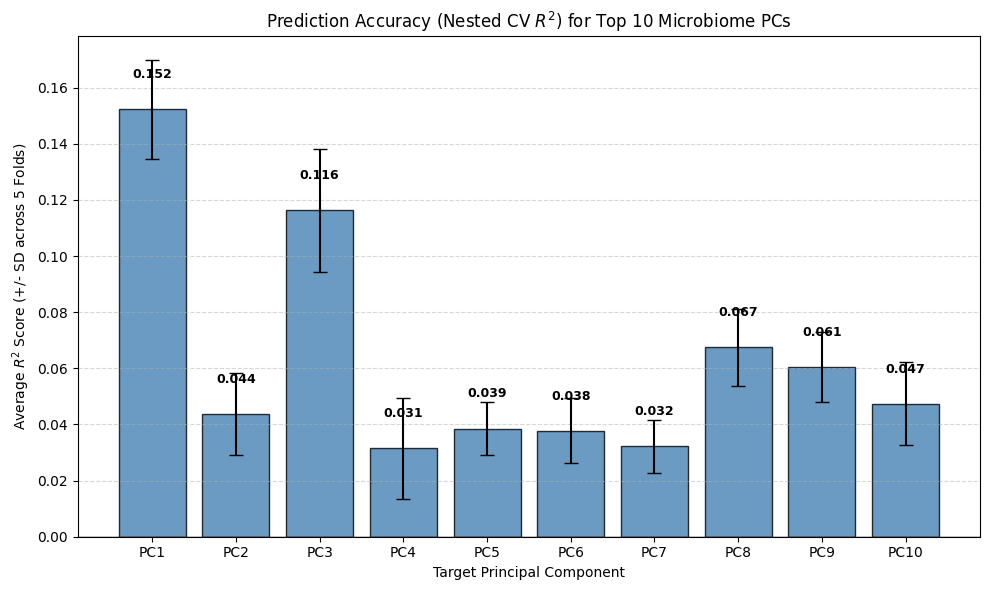


--- 7. Generating Plot for Best PC ---
Prediction scatter plot for best PC (PC1) saved.


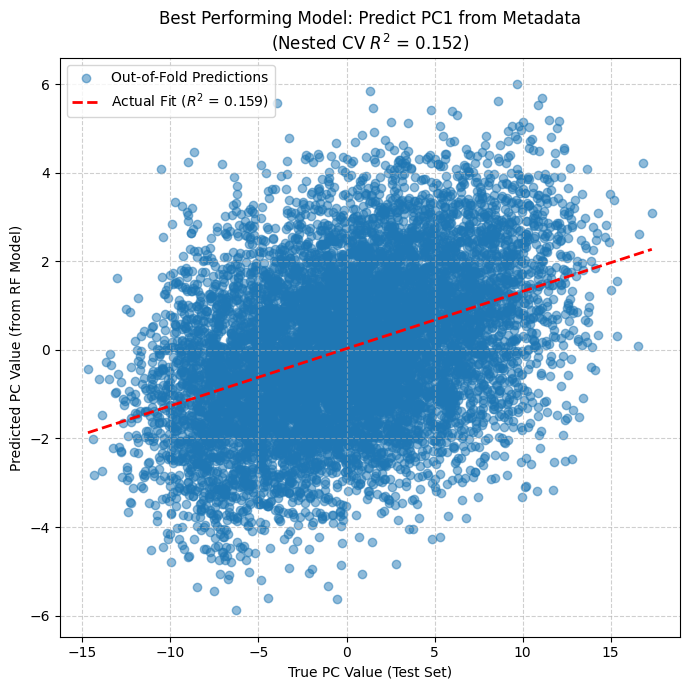


Analysis complete.

--- 8. Training FINAL (deployment) PCA + RF models on ALL AGP and saving ---
Final PCA explained variance ratio:
  PC1: 3.71%
  PC2: 2.13%
  PC3: 1.77%
  PC4: 1.43%
  PC5: 1.10%
  PC6: 1.04%
  PC7: 0.94%
  PC8: 0.82%
  PC9: 0.78%
  PC10: 0.75%
  Saved FINAL PC1: best CV R2=0.1504 | best_params={'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 300}
  Saved FINAL PC2: best CV R2=0.0446 | best_params={'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 300}
  Saved FINAL PC3: best CV R2=0.1139 | best_params={'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 300}
  Saved FINAL PC4: best CV R2=0.0317 | best_params={'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 300}
  Saved FINAL PC5: best CV R2=0.0374 | best_params={'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_lea

In [9]:
# 6. Display Final Results (unchanged) 
print("\n--- 6. Final Nested Cross-Validation Results ---")
summary_data = {
    pc: {'Mean R2': res['avg_r2'], 'Std R2': res['std_r2']}
    for pc, res in nested_cv_results.items()
}
results_df = pd.DataFrame.from_dict(summary_data, orient='index')
print(results_df)

results_df.to_csv(os.path.join(output_dir, "rf_pcr_nested_cv_results.csv"))
print(f"\nFull results saved to '{output_dir}rf_pcr_nested_cv_results.csv'")

# 6b. Performance Bar Plot with Error Bars (unchanged cosmetic) 
print("\n--- 6b. Generating Model Performance Bar Plot ---")
pc_names = list(nested_cv_results.keys())
r2_means = [nested_cv_results[pc]['avg_r2'] for pc in pc_names]
r2_stds  = [nested_cv_results[pc]['std_r2'] for pc in pc_names]

perf_df = pd.DataFrame({'PC': pc_names, 'R2': r2_means, 'Error': r2_stds})

plt.figure(figsize=(10, 6))
bars = plt.bar(perf_df['PC'], perf_df['R2'],
               yerr=perf_df['Error'],
               capsize=5,
               color='steelblue',
               edgecolor='black',
               alpha=0.8)

plt.axhline(0, color='black', linewidth=1)
plt.title(f'Prediction Accuracy (Nested CV $R^2$) for Top {n_pcs_to_predict} Microbiome PCs')
plt.xlabel('Target Principal Component')
plt.ylabel('Average $R^2$ Score (+/- SD across 5 Folds)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, r2 in zip(bars, r2_means):
    y_pos = bar.get_height() + (0.01 if r2 >= 0 else -0.04)
    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{r2:.3f}',
             ha='center', va='bottom' if r2 >= 0 else 'top',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "rf_model_performance_bar_plot.pdf"))
print(f"Performance bar plot saved to '{output_dir}rf_model_performance_bar_plot.pdf'")
plt.show()
plt.close()

# 7. Plot for Best Performing PC (keep cosmetics as-is) 
print("\n--- 7. Generating Plot for Best PC ---")
best_pc_name = results_df['Mean R2'].idxmax()
best_pc_avg_r2 = nested_cv_results[best_pc_name]['avg_r2']
true_values = nested_cv_results[best_pc_name]['y_true']
pred_values = nested_cv_results[best_pc_name]['y_pred']

true_values_reshaped = true_values.reshape(-1, 1)
line_model = LinearRegression()
line_model.fit(true_values_reshaped, pred_values)
min_val = true_values.min()
max_val = true_values.max()
line_x = np.array([min_val, max_val]).reshape(-1, 1)
line_y = line_model.predict(line_x)
line_r2 = line_model.score(true_values_reshaped, pred_values)

plt.figure(figsize=(7, 7))
plt.scatter(true_values, pred_values, alpha=0.5, label="Out-of-Fold Predictions")
plt.plot(line_x.flatten(), line_y, '--', color='red', lw=2,
         label=f"Actual Fit ($R^2$ = {line_r2:.3f})")

plt.title(f'Best Performing Model: Predict {best_pc_name} from Metadata\n(Nested CV $R^2$ = {best_pc_avg_r2:.3f})')
plt.xlabel("True PC Value (Test Set)")
plt.ylabel("Predicted PC Value (from RF Model)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"best_pc_prediction_scatter_actual_fit_{best_pc_name}.pdf"))
print(f"Prediction scatter plot for best PC ({best_pc_name}) saved.")
plt.show()

print("\nAnalysis complete.")

# Saving "deployment" models
# 1) Imports for saving
# 2) After nested CV finishes, it trains FINAL models on ALL AGP
#    - Fits OTU scaler + PCA on ALL AGP (defines the PC space you'll use for UKB projection)
#    - Trains one RF model per PC with GridSearchCV on ALL AGP
# 3) Saves:
#    - final_otu_scaler.pkl
#    - final_pca.pkl
#    - final_rf_models.pkl (dict PC1..PCk -> fitted pipeline)
#    - final_training_metadata.json (X columns, OTUs kept, params, CV scores)

print("\n--- 8. Training FINAL (deployment) PCA + RF models on ALL AGP and saving ---")

# 8.1 Fit FINAL OTU scaler + PCA on ALL AGP OTU data
# (This is the PCA basis we will use to define PC1..PCk for deployment.)
final_otu_scaler = StandardScaler()
final_Y_scaled = final_otu_scaler.fit_transform(otu_df_log_transformed.values)

final_pca = PCA(n_components=n_pcs_to_predict, random_state=random_state_cv)
final_Y_pcs = final_pca.fit_transform(final_Y_scaled)  # shape: (n_samples, n_pcs_to_predict)

print("Final PCA explained variance ratio:")
for i, v in enumerate(final_pca.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {v*100:.2f}%")

# 8.2 Train FINAL RF models (one per PC) on ALL AGP metadata with CV hyperparameter search
# (This is separate from nested CV evaluation. Here we want a final model for projection.)
final_cv = KFold(n_splits=inner_cv_splits, shuffle=True, random_state=random_state_cv)

final_rf_models = {}      # pc_name -> best_estimator_
final_rf_cv_info = {}     # pc_name -> best_params + best_cv_r2

for pc_idx in range(n_pcs_to_predict):
    pc_name = f"PC{pc_idx+1}"
    y_target_all = final_Y_pcs[:, pc_idx]

    final_grid_search = GridSearchCV(
        estimator=rf_pipe,          # uses your existing Pipeline(imputer -> rf)
        param_grid=param_grid,      # uses your existing hyperparameter grid
        cv=final_cv,                # reuse your inner_cv_splits for training-time selection
        scoring="r2",
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    final_grid_search.fit(X_metadata, y_target_all)

    final_rf_models[pc_name] = final_grid_search.best_estimator_
    final_rf_cv_info[pc_name] = {
        "best_params": final_grid_search.best_params_,
        "best_cv_r2": float(final_grid_search.best_score_)
    }

    print(f"  Saved FINAL {pc_name}: best CV R2={final_grid_search.best_score_:.4f} | best_params={final_grid_search.best_params_}")

# 8.3 Save final objects to disk (for UKB projection script)
joblib.dump(final_otu_scaler, os.path.join(model_dir, "final_otu_scaler.pkl"))
joblib.dump(final_pca,        os.path.join(model_dir, "final_pca.pkl"))
joblib.dump(final_rf_models,  os.path.join(model_dir, "final_rf_models.pkl"))

# 8.4 Save metadata needed to ensure UKB uses identical feature set / OTU set
final_training_metadata = {
    "random_state_cv": random_state_cv,
    "abundance_threshold": abundance_threshold,
    "n_pcs_to_predict": n_pcs_to_predict,
    "n_pcs_to_explore": n_pcs_to_explore,
    "outer_cv_splits": outer_cv_splits,
    "inner_cv_splits": inner_cv_splits,
    "numeric_cols_used_as_X": list(numeric_cols),
    "otus_kept_after_filter": list(otus_to_keep),
    "final_pca_explained_variance_ratio": final_pca.explained_variance_ratio_.tolist(),
    "final_rf_cv_info": final_rf_cv_info,
    "param_grid": param_grid,
}

with open(os.path.join(model_dir, "final_training_metadata.json"), "w") as f:
    json.dump(final_training_metadata, f, indent=2)

print(f"Final deployment objects saved under: {model_dir}")
print("Files written:")
print(" - final_otu_scaler.pkl")
print(" - final_pca.pkl")
print(" - final_rf_models.pkl")
print(" - final_training_metadata.json")

# --- 9. Generate Feature Importance Plots for Top 5 PCs ---
print("\n--- 9. Generating Feature Importance Plots (Top 5 PCs) ---")

# Ensure we have the feature names
feature_names = X_metadata.columns
n_top_features = 15 # Number of top features to show per PC

# Create a directory specifically for importance plots
importance_dir = os.path.join(output_dir, "Feature_Importances")
os.makedirs(importance_dir, exist_ok=True)

# Loop through the first 5 PCs (or fewer if n_pcs_to_predict < 5)
pcs_to_plot = min(5, n_pcs_to_predict)

for pc_idx in range(pcs_to_plot):
    pc_name = f"PC{pc_idx+1}"
    
    # Retrieve the trained pipeline for this PC
    model_pipeline = final_rf_models[pc_name]
    
    # Access the Random Forest step specifically
    # The step name is 'rf' as defined in your pipeline earlier
    rf_model = model_pipeline.named_steps['rf']
    
    # Get importances
    importances = rf_model.feature_importances_
    
    # Create a DataFrame for easy sorting and plotting
    imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance (descending) and take top N
    imp_df_sorted = imp_df.sort_values(by='Importance', ascending=False).head(n_top_features)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=imp_df_sorted,
        x='Importance',
        y='Feature',
        palette='viridis',
        hue='Feature',       # Added to suppress future warning
        legend=False         # Hide legend as y-axis labels serve that purpose
    )
    
    plt.title(f'Top {n_top_features} Lifestyle Predictors for {pc_name}')
    plt.xlabel('Gini Importance')
    plt.ylabel('Metadata Variable')
    plt.tight_layout()
    
    # Save plot
    save_path = os.path.join(importance_dir, f"feature_importance_{pc_name}.pdf")
    plt.savefig(save_path)
    plt.close()
    
    print(f"Saved feature importance plot for {pc_name} to '{save_path}'")

    # Optional: Print the top 3 drivers to terminal for quick check
    top_3 = imp_df_sorted['Feature'].head(3).tolist()
    print(f"  -> Top drivers for {pc_name}: {', '.join(top_3)}")

print("\nAll feature importance plots generated.")